In [1]:
import os
import time
import gc
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision.datasets import Cityscapes

import albumentations as A                      

import cv2
from albumentations.pytorch import ToTensorV2
import matplotlib.pyplot as plt

import torch.nn as nn
import torch.nn.functional as F
from tqdm.notebook import tqdm
from torch.utils.tensorboard import SummaryWriter
from torchmetrics.segmentation import MeanIoU

import segmentation_models_pytorch as smp
from transformers import SegformerForSemanticSegmentation

In [2]:
CONFIG = {
    "epochs": 2,
    "batch": 4,
    "lr": 1e-4,
    "weight_decay": 1e-4,
    "num_clases": 19,
    "seed": 42,
    "data": '../data/cityscape',
    "checkpoint_dir": "../checkpoints/benchmark2/",
    "logs_dir": "../logs/benchmark2/",
    "mem_dir": "../memoria/benchmark2/"
}

MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]

# Reduzco el tamaño de las imagenes a la mitad.
IMG_ALTO = 512
IMG_ANCHO  = 1024

torch.manual_seed(CONFIG["seed"])
np.random.seed(CONFIG["seed"])


# Crear carpetas necesarias
os.makedirs(CONFIG["checkpoint_dir"], exist_ok=True)
os.makedirs(CONFIG["logs_dir"], exist_ok=True)
os.makedirs(CONFIG["mem_dir"], exist_ok=True)

In [3]:
#### GPU Info ####
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Usando: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


In [4]:
transform_train = A.Compose([
    A.Resize(IMG_ALTO, IMG_ANCHO,
             interpolation=cv2.INTER_LINEAR,
             mask_interpolation=cv2.INTER_NEAREST),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2()
])

transform_val = A.Compose([
    A.Resize(IMG_ALTO, IMG_ANCHO,
             interpolation=cv2.INTER_LINEAR,
             mask_interpolation=cv2.INTER_NEAREST),
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2()
])

In [5]:
"""
names:
  0: road
  1: sidewalk
  2: building
  3: wall
  4: fence
  5: pole
  6: traffic light
  7: traffic sign
  8: vegetation
  9: terrain
  10: sky
  11: person
  12: rider
  13: car
  14: truck
  15: bus
  16: train
  17: motorcycle
  18: bicycle
"""

"""
label_mapping:
  -1: ignore_label
  0: ignore_label
  1: ignore_label
  2: ignore_label
  3: ignore_label
  4: ignore_label
  5: ignore_label
  6: ignore_label
  7: 0
  8: 1
  9: ignore_label
  10: ignore_label
  11: 2
  12: 3
  13: 4
  14: ignore_label
  15: ignore_label
  16: ignore_label
  17: 5
  18: ignore_label
  19: 6
  20: 7
  21: 8
  22: 9
  23: 10
  24: 11
  25: 12
  26: 13
  27: 14
  28: 15
  29: ignore_label
  30: ignore_label
  31: 16
  32: 17
  33: 18
"""

'\nlabel_mapping:\n  -1: ignore_label\n  0: ignore_label\n  1: ignore_label\n  2: ignore_label\n  3: ignore_label\n  4: ignore_label\n  5: ignore_label\n  6: ignore_label\n  7: 0\n  8: 1\n  9: ignore_label\n  10: ignore_label\n  11: 2\n  12: 3\n  13: 4\n  14: ignore_label\n  15: ignore_label\n  16: ignore_label\n  17: 5\n  18: ignore_label\n  19: 6\n  20: 7\n  21: 8\n  22: 9\n  23: 10\n  24: 11\n  25: 12\n  26: 13\n  27: 14\n  28: 15\n  29: ignore_label\n  30: ignore_label\n  31: 16\n  32: 17\n  33: 18\n'

In [6]:
ID_TO_TRAINID = {
    -1: 255,   # license plate
    0: 255,  # unlabeled
    1: 255,  # ego vehicle
    2: 255,  # rectification border
    3: 255,  # out of roi
    4: 255,  # static
    5: 255,  # dynamic
    6: 255,  # ground
    7: 0,    # road
    8: 1,    # sidewalk
    9: 255,  # parking
    10: 255,  # rail track
    11: 2,    # building
    12: 3,    # wall
    13: 4,    # fence
    14: 255,  # guard rail
    15: 255,  # bridge
    16: 255,  # tunnel
    17: 5,    # pole
    18: 255,  # polegroup
    19: 6,    # traffic light
    20: 7,    # traffic sign
    21: 8,    # vegetation
    22: 9,    # terrain
    23: 10,   # sky
    24: 11,   # person
    25: 12,   # rider
    26: 13,   # car
    27: 14,   # truck
    28: 15,   # bus
    29: 255,  # caravan
    30: 255,  # trailer
    31: 16,   # train
    32: 17,   # motorcycle
    33: 18    # bicycle
}

In [7]:
def convert_mask_id(mask):
    res_mask = np.full_like(mask, 255)
    for id_original, train_id in ID_TO_TRAINID.items():
        res_mask[mask == id_original] = train_id
    return res_mask

In [8]:
class Dataset_Cityscape(Dataset):

    def __init__(self, conjunto="train", transform=None):
        self.dataset = Cityscapes(
            root=CONFIG["data"],
            split=conjunto,
            mode="fine",
            target_type="semantic"
        )
        self.transform=transform

    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, indice:int):
        image, mask = self.dataset[indice]

        image = np.array(image)
        mask = np.array(mask)

        mask = convert_mask_id(mask)

        if self.transform:
            t = self.transform(image=image, mask=mask)
            image = t["image"]
            mask = t["mask"].long()
        return image, mask
        

In [9]:
train_data = Dataset_Cityscape(conjunto="train", transform=transform_train)
val_data = Dataset_Cityscape(conjunto="val", transform=transform_val)
test_data = Dataset_Cityscape(conjunto="test", transform=transform_val)

In [10]:
img, mascara = train_data[0]
mascara.shape

torch.Size([512, 1024])

In [11]:
train_loader = DataLoader(
    train_data,
    batch_size=CONFIG["batch"],
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_data,
    batch_size=CONFIG["batch"],
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

test_loader = DataLoader(
    test_data,
    batch_size=1,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)


In [12]:
print(f"N° imágenes de entrenamiento: {len(train_data)} imágenes | {len(train_loader)} batches")
print(f"N° imágene de validación: {len(val_data)} imágenes | {len(val_loader)} batches")
print(f"N° imágene de test: {len(test_data)} imágenes | {len(test_loader)} batches")
print(f"\n(CityScape) Número total del imágenes {len(train_data)+len(val_data)+len(test_data)}")


N° imágenes de entrenamiento: 2975 imágenes | 744 batches
N° imágene de validación: 500 imágenes | 125 batches
N° imágene de test: 1525 imágenes | 1525 batches

(CityScape) Número total del imágenes 5000


In [13]:
r = set()
for i in ID_TO_TRAINID.values():
    r.add(i)

print(f"El dataset CityScape tiene {len(r)} clases distintas.\n19 objetos y el fondo")
print(r)

El dataset CityScape tiene 20 clases distintas.
19 objetos y el fondo
{0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 255}


In [14]:
COLOR_DIC = {
    0:[128,0,0],
    1:[0,128,0],
    2:[128,128,0],
    3:[0,0,128],
    4:[128,0,128],
    5:[0,128,128],
    6:[128,128,128],
    7:[64,0,0],
    8:[0,200,0],
    9:[192,0,0],
    10:[64,128,0],
    11:[192,128,0],
    12:[64,0,128],
    13:[192,0,128],
    14:[64,128,128],
    15:[192,128,128],
    16:[0,64,0],
    17:[128,64,0],
    18:[0,192,0],
    255: [0,0,0]
}

In [15]:
def colorear_mascara(mask):
    mask_color = np.zeros((*mask.shape, 3), dtype=np.uint8)
    for k, v in COLOR_DIC.items():
        mask_color[mask == k] = v
    return mask_color

In [16]:
def desnormalizar(tensor):
    mean = torch.tensor(MEAN).view(3,1,1)
    std = torch.tensor(STD).view(3,1,1)
    return (tensor*std+mean).clamp(0,1)

In [17]:
def visualizar_ejemplos(loader, n=4):
    images, masks = next(iter(loader))
    fig, axes = plt.subplots(2, n, figsize=(4*n, 8))

    for i in range(n):
        img = desnormalizar(images[i]).permute(1,2,0).numpy()
        axes[0,i].imshow(img)
        axes[0,i].set_title("Imagen")
        axes[0,i].axis("off")

        axes[1,i].imshow(colorear_mascara(masks[i].numpy()))
        axes[1,i].set_title("Máscara")
        axes[1,i].axis("off")

    plt.suptitle("Ejemplos CityScape", fontsize=14)
    plt.tight_layout()
    plt.show()

Shape imágenes:  torch.Size([4, 3, 512, 1024])
Shape máscaras:  torch.Size([4, 512, 1024])
Clases únicas:   tensor([  0,   1,   2,   4,   5,   6,   7,   8,   9,  10,  11,  13,  15,  18,
        255])


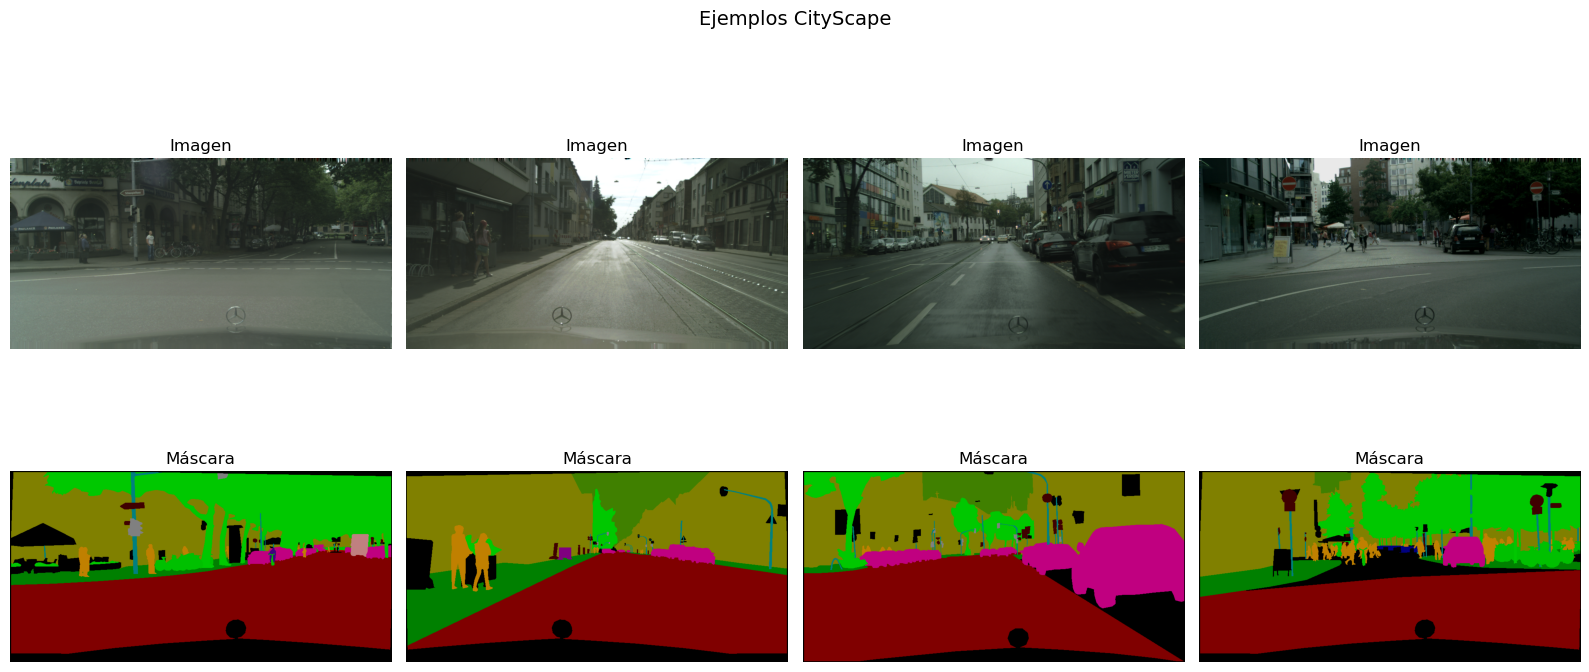

In [18]:
# Verificar shapes
images, masks = next(iter(train_loader))
print(f"Shape imágenes:  {images.shape}")
print(f"Shape máscaras:  {masks.shape}")
print(f"Clases únicas:   {masks.unique()}")

# Visualizar
visualizar_ejemplos(train_loader)

## Definir modelos.

In [19]:
# ── U-Net ──────────────────────────────────────
unet = smp.Unet(
    encoder_name="resnet50",
    encoder_weights="imagenet",
    in_channels=3,
    classes=CONFIG["num_clases"]
)

def forward_unet(model, images):
    return model(images)

print(f"** U-Net -> N° parámetros: {sum(p.numel() for p in unet.parameters())/1e6:.1f}M")
print("\n** Modelo U-Net cargado")

** U-Net -> N° parámetros: 32.5M

** Modelo U-Net cargado


In [20]:
# ── DeepLabV3+ ──────────────────────────────────
deeplabv3plus = smp.DeepLabV3Plus(
    encoder_name="resnet50",
    encoder_weights="imagenet",
    in_channels=3,
    classes=CONFIG["num_clases"]
)

def forward_deeplabv3plus(model, images):
    return model(images)

print(f"\n** DeepLabV3Plus -> N° parámetros: {sum(p.numel() for p in deeplabv3plus.parameters())/1e6:.1f}M")
print("\n** Modelo DeepLabV3Plus cargado")


** DeepLabV3Plus -> N° parámetros: 26.7M

** Modelo DeepLabV3Plus cargado


In [21]:
# ── SegFormer ──────────────────────────────────
segformer = SegformerForSemanticSegmentation.from_pretrained(
    "nvidia/mit-b2",
    num_labels=CONFIG["num_clases"],
    ignore_mismatched_sizes=True
)

def forward_segformer(model, images):
    outputs = model(pixel_values=images)
    return F.interpolate(
        outputs.logits,
        size=(IMG_ALTO, IMG_ANCHO),
        mode="bilinear",
        align_corners=False
    )

print(f"\n\n\n** SegFormer -> N° parámetros: {sum(p.numel() for p in segformer.parameters())/1e6:.1f}M")
print("\n** Modelo SegFormer cargado")

[transformers] You passed `num_labels=19` which is incompatible to the `id2label` map of length `1000`.


Loading weights:   0%|          | 0/364 [00:00<?, ?it/s]

[transformers] SegformerForSemanticSegmentation LOAD REPORT from: nvidia/mit-b2
Key                                           | Status     | 
----------------------------------------------+------------+-
classifier.bias                               | UNEXPECTED | 
classifier.weight                             | UNEXPECTED | 
decode_head.linear_c.{0, 1, 2, 3}.proj.weight | MISSING    | 
decode_head.batch_norm.running_mean           | MISSING    | 
decode_head.linear_c.{0, 1, 2, 3}.proj.bias   | MISSING    | 
decode_head.classifier.weight                 | MISSING    | 
decode_head.batch_norm.bias                   | MISSING    | 
decode_head.batch_norm.running_var            | MISSING    | 
decode_head.classifier.bias                   | MISSING    | 
decode_head.batch_norm.num_batches_tracked    | MISSING    | 
decode_head.linear_fuse.weight                | MISSING    | 
decode_head.batch_norm.weight                 | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading fr




** SegFormer -> N° parámetros: 27.4M

** Modelo SegFormer cargado


### Definición función de pérdida

In [22]:
class perdidaDiceCE(nn.Module):
    def __init__(self):
        super().__init__()
        self.dice = smp.losses.DiceLoss(
            mode="multiclass",
            ignore_index=255
        )
        self.ce = nn.CrossEntropyLoss(ignore_index=255)

    def forward(self, pred, obj):
        return 0.5 * self.dice(pred, obj) + 0.5 * self.ce(pred, obj)

loss_fn = perdidaDiceCE()
print("-> Función de pérdida definida")

-> Función de pérdida definida


In [23]:
def entrenar_modelo(modelo, nombre, forward_fn):

    modelo = modelo.to(device)
    writer  = SummaryWriter(log_dir=CONFIG["logs_dir"]+nombre)

    miou_fn = MeanIoU(
        num_classes=CONFIG["num_clases"]
    ).to(device)

    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, modelo.parameters()),
        lr=CONFIG["lr"],
        weight_decay=CONFIG["weight_decay"]
    )
    
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=CONFIG["epochs"],
        eta_min=1e-6
    )

    historial = {
        "loss_train": [],
        "miou_val":   []
    }
    tiempo_entrenamiento = 0.0
    mejor_miou = 0.0
    

    for epoch in range(CONFIG["epochs"]):

        # Aquí empieza el entrenamiento de cada epoch
        inicio_epoch = time.time()
        # -- Train ---------------------------
        modelo.train()
        loss_total = 0

        pbar = tqdm(
            train_loader,
            desc=f"[{nombre}] Epoch {epoch+1}/{CONFIG['epochs']}",
            leave=False
        )

        for images, masks in pbar:
            images = images.to(device)
            masks = masks.to(device)

            optimizer.zero_grad()
            preds = forward_fn(modelo, images)
            loss = loss_fn(preds, masks)
            loss.backward()
            optimizer.step()

            loss_total += loss.item()
            pbar.set_postfix(loss=f"{loss.item():.4f}")

        loss_media = loss_total / len(train_loader)

        

        # -- Validación ---------------------------
        modelo.eval()
        miou_fn.reset()

        with torch.no_grad():
            for images, masks in val_loader:
                images = images.to(device)
                masks  = masks.to(device)
                preds  = forward_fn(modelo, images).argmax(dim=1)
                miou_fn.update(preds, masks)

        miou_val = miou_fn.compute().item()
        scheduler.step()    # disminuye learning rate.


        # -- Guardar historial ---------------------------
        historial["loss_train"].append(loss_media)
        historial["miou_val"].append(miou_val)
        # -- Sumar tiempo epoch ---------------------------
        tiempo_epoch = (time.time() - inicio_epoch)/60 # tiempo del entrenamiento de cada epochs.
        tiempo_entrenamiento += tiempo_epoch    # Sumo tiempo de epoch en minutos.
        # -- TensorBoard ---------------------------
        writer.add_scalar("Loss/train", loss_media, epoch)
        writer.add_scalar("mIoU/val", miou_val, epoch)
        writer.add_scalar("LR", optimizer.param_groups[0]["lr"], epoch)
        writer.add_scalar("Tiempo/epoch", tiempo_epoch, epoch)

        print(f"[{nombre}] Epoch {epoch+1:02d} | Loss: {loss_media:.4f} | mIoU: {miou_val*100:.2f}% | Tiempo: {tiempo_epoch:.4f} min")

        # -- Guardar mejor modelo ---------------------------
        if miou_val > mejor_miou:
            mejor_miou = miou_val
            torch.save({
                "epoch":          epoch,
                "modelo":         modelo.state_dict(),
                "optimizer":      optimizer.state_dict(),
                "scheduler":      scheduler.state_dict(),
                "mejor_miou":     mejor_miou,
                "historial":      historial
            },
            f"{CONFIG['checkpoint_dir']}{nombre}_b2_checkpoint.pth"
            )
            print(f"  -- Guardado modelo {nombre} con mIoU = {mejor_miou*100:.2f}%")

    writer.close()
    
    print(f"\n\n-->>    {nombre} completado | Mejor mIoU: {mejor_miou*100:.2f}% | Tiempo total de entrenamiento: {tiempo_entrenamiento:.4f} min   <<--")
    
    #--- Libero memoria VRAM ------------------
    modelo.cpu()
    del modelo
    del optimizer
    del scheduler
    del miou_fn
    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.synchronize()
    #--------------------------------
    
    return mejor_miou, historial

In [24]:
# Entrenar U-net
miou_unet, hist_unet = entrenar_modelo(
    unet, "unet", forward_unet
)

[unet] Epoch 1/2:   0%|          | 0/744 [00:00<?, ?it/s]

[unet] Epoch 01 | Loss: 0.6679 | mIoU: 28.76% | Tiempo: 9.8989 min
  -- Guardado modelo unet con mIoU = 28.76%


[unet] Epoch 2/2:   0%|          | 0/744 [00:00<?, ?it/s]

[unet] Epoch 02 | Loss: 0.3915 | mIoU: 30.12% | Tiempo: 9.7457 min
  -- Guardado modelo unet con mIoU = 30.12%


-->>    unet completado | Mejor mIoU: 30.12% | Tiempo total de entrenamiento: 19.6446 min   <<--


In [25]:
#Entrenar DeepLabV3Plus
miou_deeplabv3plus, hist_deeplabv3plus = entrenar_modelo(
    deeplabv3plus, "deeplabv3plus", forward_deeplabv3plus
)

[deeplabv3plus] Epoch 1/2:   0%|          | 0/744 [00:00<?, ?it/s]

[deeplabv3plus] Epoch 01 | Loss: 0.4878 | mIoU: 26.91% | Tiempo: 8.7573 min
  -- Guardado modelo deeplabv3plus con mIoU = 26.91%


[deeplabv3plus] Epoch 2/2:   0%|          | 0/744 [00:00<?, ?it/s]

[deeplabv3plus] Epoch 02 | Loss: 0.2931 | mIoU: 30.10% | Tiempo: 8.7169 min
  -- Guardado modelo deeplabv3plus con mIoU = 30.10%


-->>    deeplabv3plus completado | Mejor mIoU: 30.10% | Tiempo total de entrenamiento: 17.4743 min   <<--


In [26]:
# Entrenar SegFormer
miou_segformer, hist_segformer = entrenar_modelo(
    segformer, "segformer", forward_segformer
)

[segformer] Epoch 1/2:   0%|          | 0/744 [00:00<?, ?it/s]

OutOfMemoryError: CUDA out of memory. Tried to allocate 384.00 MiB. GPU 0 has a total capacity of 7.62 GiB of which 309.19 MiB is free. Including non-PyTorch memory, this process has 7.30 GiB memory in use. Of the allocated memory 6.86 GiB is allocated by PyTorch, and 330.81 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://docs.pytorch.org/docs/stable/notes/cuda.html#optimizing-memory-usage-with-pytorch-cuda-alloc-conf)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Curvas mIoU
for nombre, hist in [
    ("U-Net", hist_unet),
    ("DeepLabv3plus", hist_deeplabv3plus),
    ("SegFormer", hist_segformer)
]:
    axes[0].plot(hist["miou_val"], label=nombre)

axes[0].set_title("mIoU Validación por Epoch (Benchmark 2)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("mIoU")
axes[0].legend()
axes[0].xaxis.set_major_locator(plt.MultipleLocator(2))
axes[0].grid(True)

# Curvas Loss
for nombre, hist in [
    ("U-Net", hist_unet),
    ("DeepLabv3plus", hist_deeplabv3plus),
    ("SegFormer", hist_segformer)
]:
    axes[1].plot(hist["loss_train"], label=nombre)

axes[1].set_title("Loss Train por Epoch (Benchmark 2)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].xaxis.set_major_locator(plt.MultipleLocator(2))
axes[1].grid(True)

plt.tight_layout()
plt.savefig("../memoria/benchmark2/curvas_entrenamiento_b2.png", dpi=150)
plt.show()

In [ ]:
"""
CORREGIR CODIGO PARA CARGAR SOLO LOS PESOS PARA LA INFERENCIA.
"""
def evaluar_final(nombre, modelo, forward_fn):
    modelo.load_state_dict(
        torch.load(
            f"{CONFIG['checkpoint_dir']}{nombre}_b2_best.pth",
            map_location=device
        )
    )
    modelo.eval()
    modelo = modelo.to(device)

    miou_fn = MeanIoU(num_classes=CONFIG["num_clases"]).to(device)
    tiempos = []   # Lista para guardar tiempos de inferencia por imagen de cada batch.(FPS)
    n_params = sum(p.numel() for p in modelo.parameters()) / 1e6

    # Bucle para la evaluacion de los modelos.
    with torch.no_grad():
        for images, masks in test_loader:
            images = images.to(device)
            masks = masks.to(device)

            torch.cuda.synchronize()
            inicio = time.time()
            preds = forward_fn(modelo, images).argmax(dim=1)
            torch.cuda.synchronize()
            fin = time.time()

            tiempos.append(((fin - inicio) ))    # Tiempo por imágen.
            miou_fn.update(preds, masks)

    miou = miou_fn.compute().item()
    fps  = 1.0 / np.mean(tiempos)   # Frames por segundo.

    modelo.cpu()
    del modelo
    del miou_fn
    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.synchronize()

    return {"Modelo": nombre, "mIoU (%)": round(miou*100, 2), "FPS": round(fps, 1), "Params (M)": round(n_params, 1)}

In [ ]:
unet = smp.Unet(
    encoder_name="resnet50",
    encoder_weights=None,
    in_channels=3,
    classes=CONFIG["num_clases"]
)
deeplabv3plus = smp.DeepLabV3Plus(
    encoder_name="resnet50",
    encoder_weights=None,
    in_channels=3,
    classes=CONFIG["num_clases"]
)
segformer = SegformerForSemanticSegmentation.from_pretrained(
    "nvidia/mit-b2",
    num_labels=CONFIG["num_clases"],
    ignore_mismatched_sizes=True
)

In [ ]:
# Evaluar todos los modelos.
resultados = []

res = evaluar_final("unet", unet, forward_unet)
resultados.append(res)

res = evaluar_final("deeplabv3plus", deeplabv3plus, forward_deeplabv3plus)
resultados.append(res)

res = evaluar_final("segformer", segformer, forward_segformer)
resultados.append(res)



# Tabla comparativa
df = pd.DataFrame(resultados).sort_values("mIoU (%)", ascending=False)
display(df)
df.to_csv("../memoria/benchmark2/resultados_finales_b2.csv", index=False)